# Desafio Ciência e Governança de Dados

Desenvolvido por Estevão Augusto da Fonseca Santos, Graduando em Ciência de Computação

6° Período da Universidade Federal de Lavras

## Objetivos

Tendo finalizado a seção de análise exploratória. Agora, é preciso desenvolver e testar um modelo de predição, a fim de checar a correlação de dados, e sua influência em Lavras.

In [23]:
import pandas as pd               # Manipulação e análise de dados em estruturas como DataFrames
import matplotlib.pyplot as plt   # Criação de gráficos 2D de forma flexível
import seaborn as sns             # Visualização de dados estatísticos com gráficos mais estilizados
from sklearn.linear_model import LinearRegression  # Criação de modelos de regressão linear
from sklearn.preprocessing import StandardScaler   # Padronização e normalização de dados
from sklearn.metrics import r2_score              # Avaliação de desempenho de modelos com R²
import os                          # Interação com o sistema de arquivos e funcionalidades do sistema operacional

In [24]:
# Define constantes que armazenam os caminhos que serão utilizados neste notebook

DATA_DIRECTORY_PATH = "../data"
RAW_DATA_DIRECTORY_PATH = DATA_DIRECTORY_PATH + "/raw"
PROCESSED_DATA_DIRECTORY_PATH = DATA_DIRECTORY_PATH + "/processed"
METRICS_DIRECTORY_PATH = "../metrics"

In [25]:
df_municipios = pd.read_csv(PROCESSED_DATA_DIRECTORY_PATH + "/tamanho_populacional_mun.csv")
df_alfabetizacao = pd.read_csv(PROCESSED_DATA_DIRECTORY_PATH + "/alfabetizacao_processada.csv")
df_educacao = pd.read_csv(PROCESSED_DATA_DIRECTORY_PATH + "/educacao_basica_sexo_raca_cor.csv")
df_pib = pd.read_csv(RAW_DATA_DIRECTORY_PATH + "/pip_por_municipio.csv")

In [26]:
# Normalizar para Milhoes
df_pib["pib"] = df_pib["pib"] / 1_000_000
df_pib["va"] = df_pib["va"] / 1_000_000

In [27]:
# Selecionar apenas as colunas relevantes de cada DataFrame
df_pib = df_pib[['id_municipio','pib','va']]  # PIB e Valor Adicionado por município
df_alfabetizacao = df_alfabetizacao[['id_municipio','id_municipio_nome','total_alfabetizados']]  # Total de alfabetizados por município
df_matriculas = df_educacao.groupby(['id_municipio','id_municipio_nome'])['quantidade_matricula'].sum().reset_index()  # Soma das matrículas por município
df_municipios = df_municipios[['id_municipio','id_municipio_nome','populacao_total','NM_UF_SIGLA','NM_UF','AR_MUN_2024']]  # Informações gerais dos municípios

# Merge sequencial dos DataFrames, combinando informações pelos IDs dos municípios
df = df_municipios.merge(df_alfabetizacao, on=['id_municipio','id_municipio_nome'], how='left')  # Adiciona dados de alfabetização
df = df.merge(df_matriculas, on=['id_municipio','id_municipio_nome'], how='left')  # Adiciona dados de matrículas
df = df.merge(df_pib, on='id_municipio', how='left')  # Adiciona dados de PIB


In [28]:
# Carregar o arquivo CSV com os indicadores do município de Lavras
lavras = pd.read_csv(PROCESSED_DATA_DIRECTORY_PATH + "/indicadores_lavras_completo.csv")

# Calcular a taxa de matrícula em relação à população total (em %)
lavras["taxa_matricula"] = (lavras["total_matriculas"] / lavras["populacao_total"]) * 100

# Calcular o PIB per capita dividindo o PIB em milhões pela taxa de matrícula
lavras["pib_per_capita"] = (lavras["pib_milhoes"] / lavras["taxa_matricula"])


In [29]:
print(lavras)

   id_municipio municipio  populacao_total  total_alfabetizados  \
0       3138203    Lavras           105756                84907   

   taxa_alfabetizacao  total_matriculas  pib_milhoes  va_total_milhoes  \
0           80.285752             20105     2941.931          2572.287   

   populacao_estado_mg  proporcao_pop_estado_mg  rank_alfabetizacao_mg  \
0             21411923                 0.493912                  105.0   

   rank_populacao_mg  rank_alfabetizacao_brasil  rank_populacao_brasil  \
0               33.0                      819.0                  308.0   

   taxa_matricula  pib_per_capita  
0       19.010742      154.750985  


In [30]:
# Selecionar apenas as colunas relevantes de cada DataFrame
df_pib = df_pib[['id_municipio','pib','va']]  # PIB e Valor Adicionado por município
df_alfabetizacao = df_alfabetizacao[['id_municipio','id_municipio_nome','total_alfabetizados']]  # Total de alfabetizados por município
df_matriculas = df_educacao.groupby(['id_municipio','id_municipio_nome'])['quantidade_matricula'].sum().reset_index()  # Soma das matrículas por município
df_municipios = df_municipios[['id_municipio','id_municipio_nome','populacao_total','NM_UF_SIGLA','NM_UF','AR_MUN_2024']]  # Informações gerais dos municípios

# -------------------------------
# Merge sequencial sem duplicação
# -------------------------------
df = df_municipios.merge(df_alfabetizacao, on=['id_municipio','id_municipio_nome'], how='left')  # Adiciona dados de alfabetização
df = df.merge(df_matriculas, on=['id_municipio','id_municipio_nome'], how='left')  # Adiciona dados de matrículas
df = df.merge(df_pib, on='id_municipio', how='left')  # Adiciona dados de PIB e Valor Adicionado

# -------------------------------
# Criar colunas normalizadas (antes de qualquer análise)
# -------------------------------
# Evitar divisão por zero caso populacao_total tenha zeros
df['pib_per_capita'] = df['pib'] / df['populacao_total'].replace(0, pd.NA)  # PIB per capita
df['va_per_capita'] = df['va'] / df['populacao_total'].replace(0, pd.NA)    # Valor Adicionado per capita
df['taxa_alfabetizacao'] = df['total_alfabetizados'] / df['populacao_total'].replace(0, pd.NA)  # Proporção de alfabetizados
df['taxa_matricula'] = df['quantidade_matricula'] / df['populacao_total'].replace(0, pd.NA)     # Proporção de matriculados

# Conferir se as colunas foram criadas corretamente
print(df[['pib_per_capita','va_per_capita','taxa_alfabetizacao','taxa_matricula']].head())


   pib_per_capita  va_per_capita  taxa_alfabetizacao  taxa_matricula
0        0.032620       0.030417            0.686045        0.239563
1        0.028878       0.025098            0.641010        0.224412
2        0.047052       0.044843            0.754292        0.277876
3        0.032313       0.027863            0.752800        0.253680
4        0.046186       0.037987            0.716683        0.242603


Matriz de correlação:
                     pib_per_capita  va_per_capita  taxa_alfabetizacao  \
pib_per_capita            1.000000       0.994686            0.327603   
va_per_capita             0.994686       1.000000            0.314240   
taxa_alfabetizacao        0.327603       0.314240            1.000000   
taxa_matricula           -0.026441      -0.022127            0.029803   

                    taxa_matricula  
pib_per_capita           -0.026441  
va_per_capita            -0.022127  
taxa_alfabetizacao        0.029803  
taxa_matricula            1.000000  


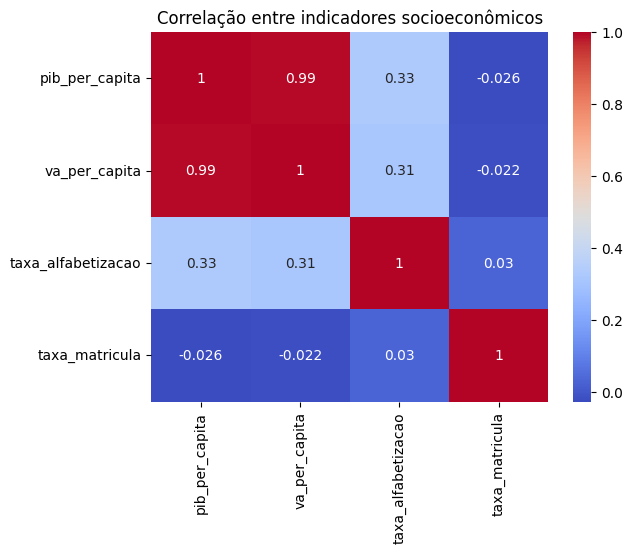

In [31]:
# Calcular a matriz de correlação entre os indicadores selecionados
corr_matrix = df[['pib_per_capita','va_per_capita','taxa_alfabetizacao','taxa_matricula']].corr()
print("Matriz de correlação:\n", corr_matrix)  # Exibir a matriz no console

# Criar um heatmap da matriz de correlação usando Seaborn
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')  # Heatmap com valores anotados e cores 'coolwarm'
plt.title('Correlação entre indicadores socioeconômicos')  # Título do gráfico

# Salvar a figura em alta resolução no diretório especificado
plt.savefig(os.path.join(METRICS_DIRECTORY_PATH + "/", 'matriz_correlacao_lavras.png'), dpi=300, bbox_inches='tight')

plt.show()   # Exibir o gráfico
plt.close()  # Fechar a figura para liberar memória


In [32]:
features = ['taxa_alfabetizacao','taxa_matricula','populacao_total']
target = 'pib_per_capita'

X = df[features]
y = df[target]

# Padronizar variáveis
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Treinar modelo
model = LinearRegression()
model.fit(X_scaled, y)

# Predizer PIB per capita de Lavras
lavras_scaled = scaler.transform(lavras[features])
pred_pib_lavras = model.predict(lavras_scaled)[0]

print(f"PIB per capita real de Lavras: {lavras['pib_per_capita'].values[0]:.2f} milhões por pessoa")
print(f"PIB per capita previsto pelo modelo: {pred_pib_lavras:.2f} milhões por pessoa")

# Avaliação do modelo
y_pred = model.predict(X_scaled)
r2 = r2_score(y, y_pred)
print(f"R² do modelo: {r2:.2f}")

PIB per capita real de Lavras: 154.75 milhões por pessoa
PIB per capita previsto pelo modelo: 8.15 milhões por pessoa
R² do modelo: 0.11


C:\Users\Maurício\AppData\Local\Temp\ipykernel_804\436062007.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='impacto', y='agente', palette='viridis')


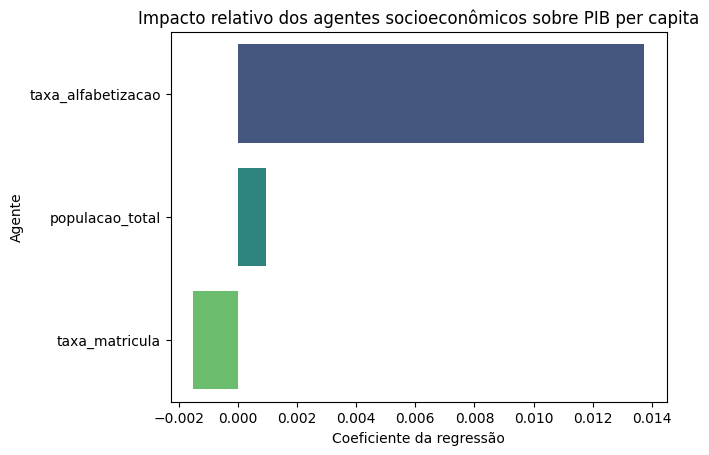

In [33]:
# Criar um DataFrame com os coeficientes do modelo para cada variável (agente)
coef_df = pd.DataFrame({
    'agente': features,       # Nomes das variáveis independentes
    'impacto': model.coef_    # Coeficientes da regressão linear
})

# Ordenar o DataFrame pelos coeficientes em ordem decrescente
coef_df = coef_df.sort_values('impacto', ascending=False)

# Criar um gráfico de barras mostrando o impacto relativo de cada agente
sns.barplot(data=coef_df, x='impacto', y='agente', palette='viridis')
plt.title('Impacto relativo dos agentes socioeconômicos sobre PIB per capita')  # Título do gráfico
plt.xlabel('Coeficiente da regressão')  # Label do eixo X
plt.ylabel('Agente')                     # Label do eixo Y

# Salvar a figura em alta resolução
plt.savefig(os.path.join(METRICS_DIRECTORY_PATH + "/", 'impacto_rel_agentes_socioeconomicos_pib_per_capita.png'), dpi=300, bbox_inches='tight')

plt.show()   # Exibir o gráfico
plt.close()  # Fechar a figura para liberar memória
